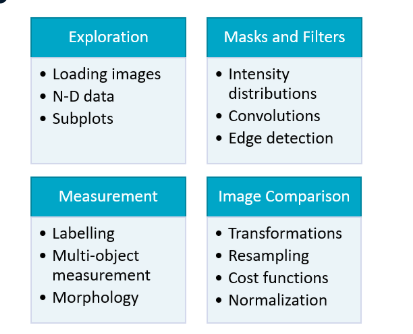

## Workflow for image processing

## Identifying potential confounds
Once measures have been extracted, double-check for dependencies within your data. This is especially true if any image parameters (sampling rate, field of view) might differ between subjects, or you pull multiple measures from a single image.

For the final exercises, we have combined demographic and brain volume measures into a pandas DataFrame (df).

First, you will explore the table and available variables. Then, you will check for correlations between the data.

Print three random rows in df using the .sample() method.




In [ ]:
# Print random sample of rows
print(df.sample(3))
           age sex  alzheimers  brain_vol  skull_vol
OAS1_0456   61   M       False   1038.965   1587.330
OAS1_0205   75   M        True   1054.239   2001.081
OAS1_0139   72   F       False    992.745   1426.764

Print the unique number of individuals with Alzheimer's disease patients.




In [ ]:
# Print random sample of rows
print(df.sample(3))

# Print prevalence of Alzheimer's Disease
print(df.alzheimers.value_counts())

           age sex  alzheimers  brain_vol  skull_vol
OAS1_0205   75   M        True   1054.239   2001.081
OAS1_0180   80   F       False    956.340   1552.306
OAS1_0244   80   F       False    823.442   1258.909

False    94
True     93
Name: alzheimers, dtype: int64

Print the correlation table between each variable.




In [ ]:
# Print a correlation table
print(df.corr())

              age  alzheimers  brain_vol  skull_vol
    age         1.000       0.037     -0.328      0.027
    alzheimers  0.037       1.000     -0.143      0.163
    brain_vol  -0.328      -0.143      1.000      0.690
    skull_vol   0.027       0.163      0.690      1.000

## Testing group differences
Let's test the hypothesis that Alzheimer's Disease is characterized by reduced brain volume.

Sample Segmentations of Alzheimer's and Typical Subject

We can perform a two-sample t-test between the brain volumes of elderly adults with and without Alzheimer's Disease. In this case, the two population samples are independent from each other because they are all separate subjects.

For this exercise, use the OASIS dataset (df) and ttest_ind to evaluate the hypothesis.

Create a vector of 'brain_vol' values for each of the Alzheimer's Disease and Typical Elderly groups.

In [ ]:
# Import independent two-sample t-test
from scipy.stats import ttest_ind

# Select data from "alzheimers" and "typical" groups
brain_alz = df.loc[df.alzheimers == True, 'brain_vol']
brain_typ = df.loc[df.alzheimers == False, 'brain_vol']

Use ttest_ind() to test for differences between the two groups' 'gray_vol' metrics. Print the results.

In [ ]:
# Perform t-test of "alz" > "typ"
results = ttest_ind(brain_alz, brain_typ)
print('t = ', results.statistic)
print('p = ', results.pvalue)

t =  -1.9646603431952554
    p =  0.050951046028341454

Visualize the 'brain_vol' measures using the boxplot() method of df. Group the variables by their disease classification by setting by='alzheimers'.

In [ ]:
# Show boxplot of brain_vol differences
df.boxplot(column='brain_vol', by='alzheimers')
plt.show()

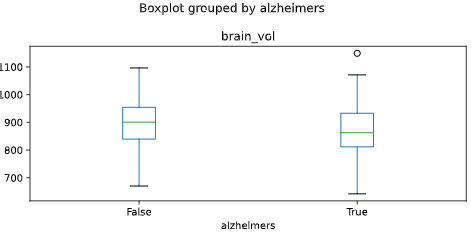

There is some evidence for decreased brain volume in individuals with Alzheimer's Disease. Since the p-value for this t-test is greater than 0.05, we would not reject the null hypothesis that states the two groups are equal.

## Normalizing metrics
We previously saw that there was not a significant difference between the brain volumes of elderly individuals with and without Alzheimer's Disease.

But could a correlated measure, such as "skull volume" be masking the differences?

For this exercise, calculate a new test statistic for the comparison of brain volume between groups, after adjusting for the subject's skull size.

Using results.statistic and results.pvalue as your guide, answer the question: Is there strong evidence that Alzheimer's Disease is marked by smaller brain size, relative to skull size?

- Import ttest_ind from scipy.stats.
- Divide each patient's brain_vol by their skull_vol to create a normalized measure.
- Extract the adjusted brain measures from each group using df.loc.
- Calculate the t-statistic and p-value using ttest_ind. Be sure to pass in brain_alz first, followed by brain_typ.

In [ ]:
# Import independent two-sample t-test
from scipy.stats import ttest_ind

# Divide `df.brain_vol` by `df.skull_vol`
df['adj_brain_vol'] = df.brain_vol / df.skull_vol

# Select brain measures by Alzheimers group
brain_alz = df.loc[df.alzheimers == True, 'adj_brain_vol']
brain_typ = df.loc[df.alzheimers == False, 'adj_brain_vol']

# Evaluate null hypothesis
results = ttest_ind(brain_alz, brain_typ)
results.statistic
results.pvalue
-5.850136931483199
2.190279428499085e-08

Using results.statistic and results.pvalue as your guide, answer the question: Is there strong evidence that Alzheimer's Disease is marked by smaller brain size, relative to skull size?